# Day 33 — Matplotlib Visualization
**Week 6: Pandas & Data Visualization**
**Topics covered:** `plt.plot()`, `plt.bar()`, `plt.barh()`, `plt.scatter()`, `plt.hist()`, `plt.pie()`, `plt.subplot()`, `fig, ax = plt.subplots()`, titles, labels, legends, `plt.tight_layout()`, `plt.savefig()`, color and style options
 
---
 
## Dataset
**Name:** `Global Air Quality Data(15 Days Hourly, 50 Cities)`
**URL:** `https://www.kaggle.com/datasets/smeet888/global-air-quality-data15-days-hourly-50-cities`
**Download:**
```python
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smeet888/global-air-quality-data15-days-hourly-50-cities")

print("Path to dataset files:", path)
```
**Key Columns:** `City`, `Country`, `AQI Value`, `AQI Category`, `CO AQI Value`, `Ozone AQI Value`, `NO2 AQI Value`, `PM2.5 AQI Value`
 
---

**Q1.** Load the dataset. Import `matplotlib.pyplot as plt`. Print `.shape` and `.head()` to understand the data. Set a consistent figure style by adding `plt.style.use('ggplot')` at the top of your notebook.
 

In [1]:
# Q1: Load Titanic dataset and display first 5 and last 3 rows

import pandas as pd
import kagglehub, os

# Get path to downloaded dataset
path = kagglehub.dataset_download("smeet888/global-air-quality-data15-days-hourly-50-cities")

# Find the CSV file inside the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("=== First 5 rows ===")
print(df.head())

print("\n=== Last 3 rows ===")
print(df.tail(3))

100%|█████████████████████████| 585k/585k [00:01<00:00, 429kB/s]

Extracting files...
=== First 5 rows ===
                    timestamp country      city  latitude  longitude    pm25  \
0  2025-11-04 18:25:17.554219      US  New York    40.713    -74.006  50.295   
1  2025-11-04 19:25:17.554219      US  New York    40.713    -74.006  32.083   
2  2025-11-04 20:25:17.554219      US  New York    40.713    -74.006  42.250   
3  2025-11-04 21:25:17.554219      US  New York    40.713    -74.006  30.403   
4  2025-11-04 22:25:17.554219      US  New York    40.713    -74.006  21.083   

      pm10     no2    so2      o3     co  aqi  temperature  humidity  \
0  108.938  27.998  6.539  52.568  1.096  108       18.504    70.168   
1   63.043  36.120  4.021  43.536  1.075   90        5.838    80.088   
2   82.553  26.935  9.538  23.320  0.977   84       31.833    62.783   
3   79.951  63.536  7.609  31.369  0.230  158       23.140    89.153   
4   66.423  38.997  6.919  45.615  1.085   97       13.632    76.499   

   wind_speed  
0       3.725  
1       8.969

In [2]:
print(df.columns)

Index(['timestamp', 'country', 'city', 'latitude', 'longitude', 'pm25', 'pm10',
       'no2', 'so2', 'o3', 'co', 'aqi', 'temperature', 'humidity',
       'wind_speed'],
      dtype='str')


**Q2.** Create a **horizontal bar chart** showing the top 10 cities by `AQI Value`. Add a title `"Top 10 Most Polluted Cities"`, label the x-axis `"AQI Value"`, and color the bars `"tomato"`. Call `plt.tight_layout()` before showing.

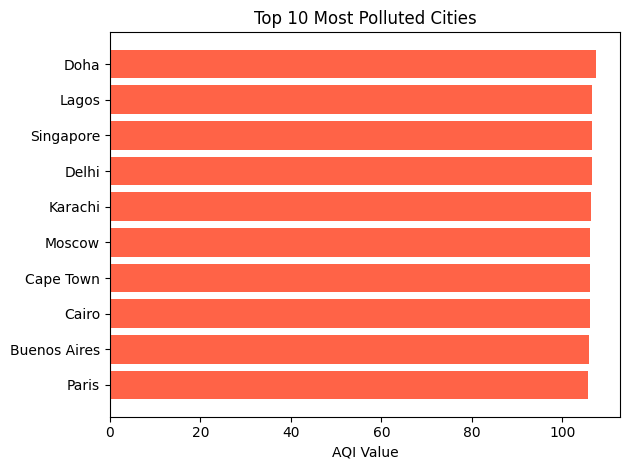

In [3]:
# Q2: Horizontal bar chart — top 10 cities by AQI value

import matplotlib.pyplot as plt

# Step 1: Get top 10 cities by AQI (highest first)
top10 = df.groupby('city')['aqi'].mean().nlargest(10).sort_values()
# NOTE: dataset column is 'aqi', not 'AQI Value'

# Step 2: Create horizontal bar chart
plt.barh(top10.index, top10.values, color='tomato')

# Step 3: Add title and axis label
plt.title('Top 10 Most Polluted Cities')
plt.xlabel('AQI Value')

plt.tight_layout()
plt.show()

### How it works

- `groupby('city')['aqi'].mean()` calculates the average AQI for each city across all time records.
- `.nlargest(10)` keeps only the top 10 highest-AQI cities.
- `.sort_values()` sorts them ascending — so the longest bar appears at the top in a horizontal chart.
- `plt.barh()` draws a **horizontal** bar chart (h = horizontal). First argument is the y-axis labels (city names), second is bar lengths (AQI values).
- `color='tomato'` sets all bars to a built-in named color in Matplotlib.
- `plt.tight_layout()` prevents the city name labels from being cut off at the edge.

**Key takeaway:** Use `plt.barh()` for horizontal bars — it is easier to read long category names (like city names) on the y-axis than squeezed on the x-axis.

**Q3.** Create a **histogram** of the `AQI Value` column with 30 bins. Set the color to `"steelblue"` and edge color to `"white"`. Add a title and axis labels. Add a vertical dashed red line at the **mean AQI** using `plt.axvline()`.
 

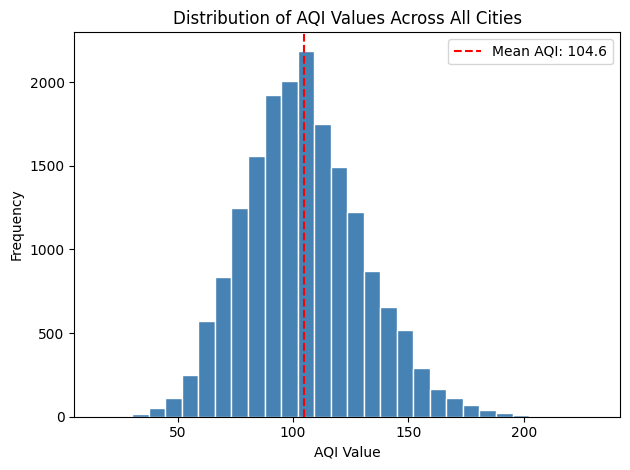

In [4]:
# Q3: Histogram of AQI with mean line

import matplotlib.pyplot as plt

# Step 1: Compute mean AQI
mean_aqi = df['aqi'].mean()

# Step 2: Draw histogram
plt.hist(df['aqi'].dropna(), bins=30, color='steelblue', edgecolor='white')

# Step 3: Add vertical dashed red line at mean
plt.axvline(mean_aqi, color='red', linestyle='--', label=f'Mean AQI: {mean_aqi:.1f}')

# Step 4: Title, labels, legend
plt.title('Distribution of AQI Values Across All Cities')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

### How it works

- `plt.hist()` divides the AQI range into 30 equal-width **bins** (buckets) and counts how many values fall in each bin.
- `edgecolor='white'` draws a thin white border between bars, making individual bins easier to distinguish.
- `df['aqi'].dropna()` removes missing values before plotting — Matplotlib will error or warn otherwise.
- `plt.axvline()` draws a vertical line across the entire y-axis at the given x position (the mean).
- `linestyle='--'` makes the line dashed; `label=f'Mean AQI: {mean_aqi:.1f}'` adds it to the legend with the actual value.
- `plt.legend()` must be called after `axvline()` for the label to appear.

**Key takeaway:** `plt.axvline()` is used to mark a reference point (like mean or threshold) on a histogram — it shows where the distribution is centered relative to that value.

**Q4.** Create a **pie chart** showing the proportion of each `AQI Category` (e.g., Good, Moderate, Unhealthy, etc.). Use `autopct='%1.1f%%'` to show percentages. Add a title.

aqi_category
Unhealthy for Sensitive Groups    8874
Moderate                          8108
Unhealthy                          840
Good                               171
Very Unhealthy                       7
Name: count, dtype: int64


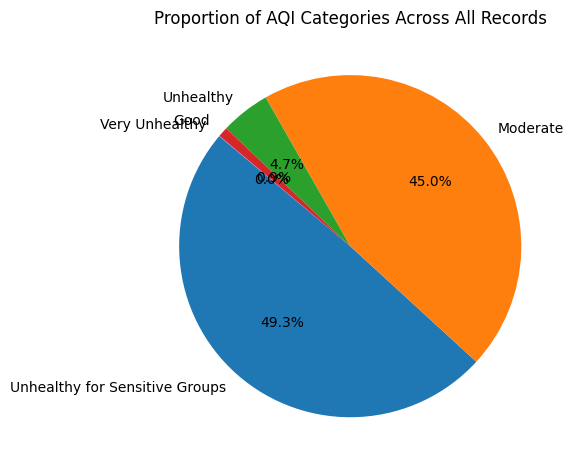

In [5]:
# Q4: Pie chart of AQI categories (derived from 'aqi' column)

import matplotlib.pyplot as plt

# Step 1: Define a function to map numeric AQI to standard category labels
def aqi_category(val):
    if val <= 50:
        return 'Good'
    elif val <= 100:
        return 'Moderate'
    elif val <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif val <= 200:
        return 'Unhealthy'
    elif val <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

# Step 2: Create the category column
df['aqi_category'] = df['aqi'].apply(aqi_category)

# Step 3: Count records per category
category_counts = df['aqi_category'].value_counts()
print(category_counts)

# Step 4: Draw pie chart
plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140        # rotate so slices don't overlap labels
)

plt.title('Proportion of AQI Categories Across All Records')
plt.tight_layout()
plt.show()

### How it works

- Your dataset has no `aqi_category` column, so we create one by mapping numeric `aqi` to standard EPA AQI labels using a helper function.
- `.apply(aqi_category)` runs that function on every row and stores the result in a new column.
- `.value_counts()` counts how many records fall into each category — this becomes the slice size.
- `plt.pie()` takes the counts as slice sizes and `labels` as the text shown beside each slice.
- `autopct='%1.1f%%'` tells Matplotlib to print the percentage inside each slice, formatted to 1 decimal place (e.g. `23.4%`).
- `startangle=140` rotates the first slice so labels on small slices are less likely to overlap.

**Key takeaway:** `autopct` is the key argument for pie charts — it controls whether and how percentages appear inside slices; the `%%` at the end is needed to print a literal `%` sign inside the format string.

**Q5.** Create a **scatter plot** of `pm25` (x-axis) vs `aqi` (y-axis). Use `alpha=0.4` for transparency. Color the points `"purple"`. Add axis labels and a title.

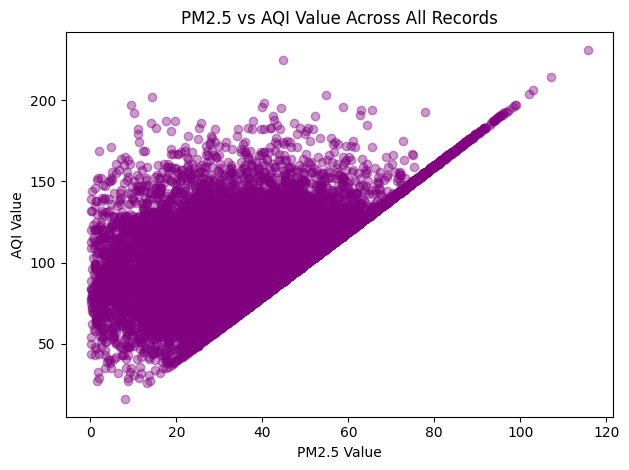

In [6]:
# Q5: Scatter plot of pm25 vs aqi

import matplotlib.pyplot as plt

# Step 1: Drop rows where either column is missing
scatter_df = df[['pm25', 'aqi']].dropna()

# Step 2: Draw scatter plot
plt.scatter(
    scatter_df['pm25'],
    scatter_df['aqi'],
    alpha=0.4,           # transparency — overlapping points stay visible
    color='purple'
)

# Step 3: Axis labels and title
plt.xlabel('PM2.5 Value')
plt.ylabel('AQI Value')
plt.title('PM2.5 vs AQI Value Across All Records')

plt.tight_layout()
plt.show()

### How it works

- `plt.scatter()` plots one dot per row — the x position comes from `pm25`, the y position from `aqi`.
- `alpha=0.4` sets 60% transparency on each point. When thousands of points overlap, transparent dots show **density** — darker areas mean more data points pile up there.
- `dropna()` on both columns together removes any row where either value is missing, which prevents mismatched x/y lengths.
- A scatter plot is the right tool here because both axes are **continuous numeric** values, and we want to see if a relationship (correlation) exists between PM2.5 and overall AQI.

**Key takeaway:** `alpha` is essential in scatter plots with large datasets — without it, overlapping points merge into a solid blob and you lose all sense of where data is concentrated.

**Q6.** Create a **grouped bar chart** comparing the average `co`, `O3`, and `no2` for the top 5 countries by number of cities. Each country gets a group of 3 bars side by side. Add a legend.

Top 5 countries: ['IN', 'US', 'AU', 'CA', 'CN']
               co         o3        no2
country                                
AU       0.791719  48.271247  31.588029
CA       0.797586  46.920361  31.626839
CN       0.792401  48.017615  32.018786
IN       0.815755  47.948462  31.996357
US       0.796457  48.608489  31.375478


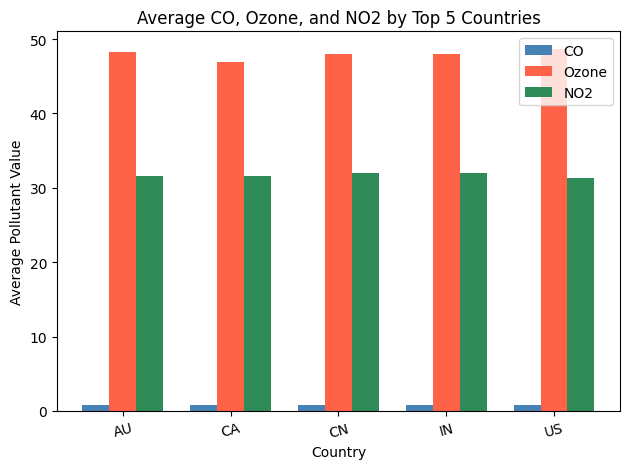

In [7]:
# Q6: Grouped bar chart — avg co, o3, no2 for top 5 countries by city count

import matplotlib.pyplot as plt
import numpy as np

# Step 1: Find top 5 countries by number of unique cities
top5_countries = (
    df.groupby('country')['city']
    .nunique()                      # count distinct cities per country
    .nlargest(5)
    .index
    .tolist()
)
print("Top 5 countries:", top5_countries)

# Step 2: Filter df to those countries and compute average pollutant values
filtered = df[df['country'].isin(top5_countries)]
grouped = filtered.groupby('country')[['co', 'o3', 'no2']].mean()
print(grouped)

# Step 3: Set up bar positions
n_countries = len(grouped)
n_pollutants = 3
x = np.arange(n_countries)         # one tick position per country
bar_width = 0.25                    # width of each individual bar

# Step 4: Draw 3 sets of bars, each offset by bar_width
plt.bar(x - bar_width, grouped['co'],  width=bar_width, label='CO',    color='steelblue')
plt.bar(x,             grouped['o3'],  width=bar_width, label='Ozone', color='tomato')
plt.bar(x + bar_width, grouped['no2'], width=bar_width, label='NO2',   color='seagreen')

# Step 5: Labels, title, legend
plt.xticks(ticks=x, labels=grouped.index, rotation=15)
plt.xlabel('Country')
plt.ylabel('Average Pollutant Value')
plt.title('Average CO, Ozone, and NO2 by Top 5 Countries')
plt.legend()

plt.tight_layout()
plt.show()

### How it works

- `groupby('country')['city'].nunique()` counts how many **distinct** cities each country has — `.nlargest(5)` keeps the top 5.
- `.groupby('country')[['co', 'o3', 'no2']].mean()` computes one average per pollutant per country — this becomes our bar heights.
- `np.arange(n_countries)` creates evenly spaced tick positions `[0, 1, 2, 3, 4]` — one slot per country group.
- Each pollutant's bars are shifted left or right of the center tick by `bar_width` so they sit **side by side** without overlapping.
- `plt.xticks(ticks=x, labels=grouped.index)` places country names at the center of each group of 3 bars.
- `plt.legend()` maps each bar color to its pollutant label.

**Key takeaway:** Grouped bars use `np.arange()` for center positions and manual offsets (`x - width`, `x`, `x + width`) to place multiple bars side by side at each tick — the trick is that all groups share the same x positions, just shifted.

**Q7.** Create a **2x2 subplot grid** (`plt.subplots(2, 2)`) with:
- Top-left: histogram of `co`
- Top-right: histogram of `o3`
- Bottom-left: histogram of `no2`
- Bottom-right: histogram of `pm25`
Add individual titles to each subplot. Call `plt.tight_layout()`.

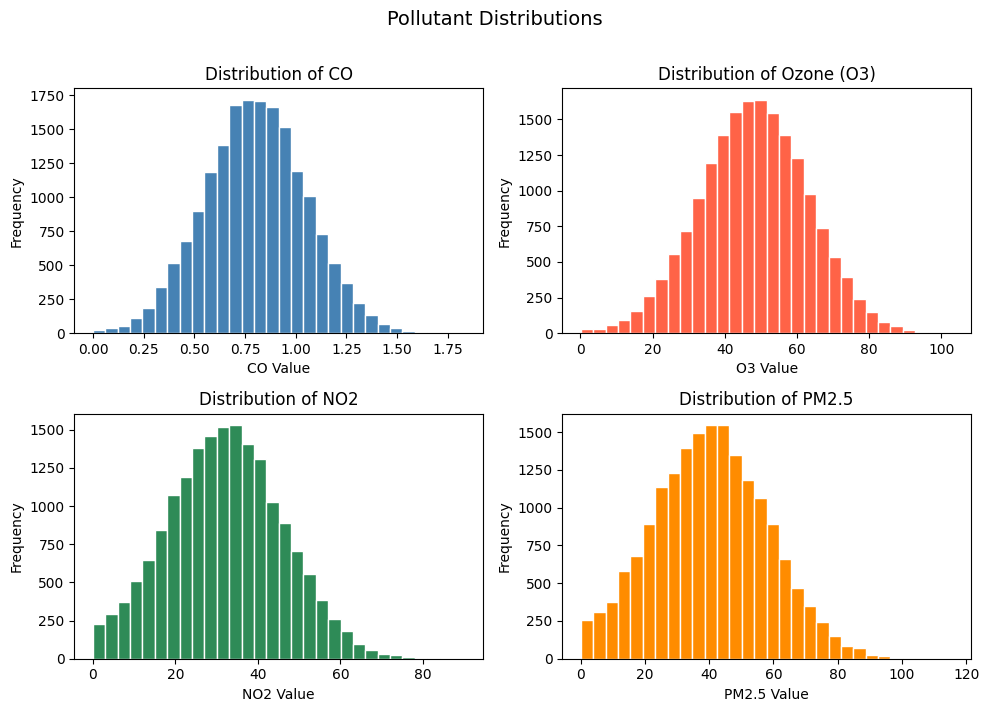

In [8]:
# Q7: 2x2 subplot grid — histograms of co, o3, no2, pm25

import matplotlib.pyplot as plt

# Step 1: Create 2x2 grid of subplots
fig, ax = plt.subplots(2, 2, figsize=(10, 7))

# Step 2: Top-left — CO
ax[0, 0].hist(df['co'].dropna(), bins=30, color='steelblue', edgecolor='white')
ax[0, 0].set_title('Distribution of CO')
ax[0, 0].set_xlabel('CO Value')
ax[0, 0].set_ylabel('Frequency')

# Step 3: Top-right — Ozone
ax[0, 1].hist(df['o3'].dropna(), bins=30, color='tomato', edgecolor='white')
ax[0, 1].set_title('Distribution of Ozone (O3)')
ax[0, 1].set_xlabel('O3 Value')
ax[0, 1].set_ylabel('Frequency')

# Step 4: Bottom-left — NO2
ax[1, 0].hist(df['no2'].dropna(), bins=30, color='seagreen', edgecolor='white')
ax[1, 0].set_title('Distribution of NO2')
ax[1, 0].set_xlabel('NO2 Value')
ax[1, 0].set_ylabel('Frequency')

# Step 5: Bottom-right — PM2.5
ax[1, 1].hist(df['pm25'].dropna(), bins=30, color='darkorange', edgecolor='white')
ax[1, 1].set_title('Distribution of PM2.5')
ax[1, 1].set_xlabel('PM2.5 Value')
ax[1, 1].set_ylabel('Frequency')

plt.suptitle('Pollutant Distributions', fontsize=14, y=1.01)  # overall title
plt.tight_layout()
plt.show()

### How it works

- `plt.subplots(2, 2)` returns a `fig` object and a 2D `ax` array of shape `(2, 2)` — think of it as a table of 4 empty plot slots.
- Each subplot is accessed by its row and column index: `ax[0, 0]` is top-left, `ax[1, 1]` is bottom-right.
- On each `ax` object we call `.hist()`, `.set_title()`, `.set_xlabel()`, `.set_ylabel()` — these are the **object-oriented** equivalents of `plt.hist()`, `plt.title()`, etc.
- Different colors per subplot make it easy to distinguish panels at a glance.
- `plt.suptitle()` adds one overall title above all subplots; `y=1.01` nudges it up slightly so it doesn't overlap the individual subplot titles.
- `plt.tight_layout()` automatically adjusts spacing between subplots so titles and labels never overlap.

**Key takeaway:** With `fig, ax = plt.subplots(2, 2)`, you control each panel independently via `ax[row, col]` — this object-oriented style is the standard approach whenever you have more than one subplot.

**Q8.** Create a **line plot** showing the mean `AQI Value` for each `AQI Category` ordered from best to worst air quality. Add markers (`marker='o'`), a title, and axis labels.

aqi_category
Good                               43.456140
Moderate                           83.622842
Unhealthy for Sensitive Groups    119.438359
Unhealthy                         162.850000
Very Unhealthy                    212.142857
Name: aqi, dtype: float64


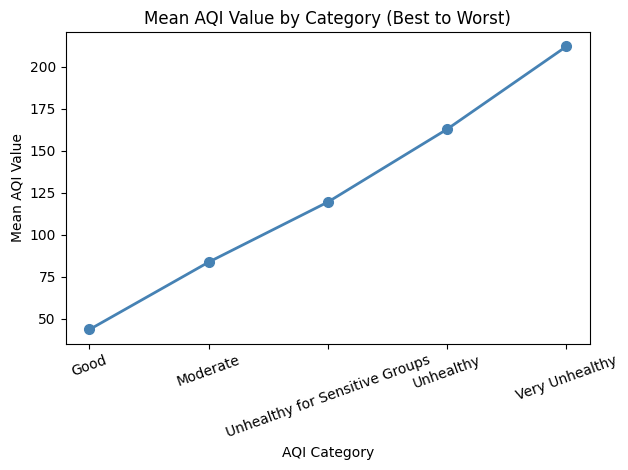

In [9]:
# Q8: Line plot — mean AQI per category ordered best to worst

import matplotlib.pyplot as plt

# Step 1: Define correct order from best to worst air quality
category_order = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

# Step 2: Create aqi_category column if not already present (reused from Q4)
def aqi_category(val):
    if val <= 50:   return 'Good'
    elif val <= 100: return 'Moderate'
    elif val <= 150: return 'Unhealthy for Sensitive Groups'
    elif val <= 200: return 'Unhealthy'
    elif val <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

if 'aqi_category' not in df.columns:
    df['aqi_category'] = df['aqi'].apply(aqi_category)

# Step 3: Compute mean AQI per category
mean_by_cat = df.groupby('aqi_category')['aqi'].mean()

# Step 4: Reindex to enforce best → worst order, drop missing categories
mean_by_cat = mean_by_cat.reindex(
    [c for c in category_order if c in mean_by_cat.index]
)
print(mean_by_cat)

# Step 5: Draw line plot with markers
plt.plot(
    mean_by_cat.index,
    mean_by_cat.values,
    marker='o',
    color='steelblue',
    linewidth=2,
    markersize=7
)

# Step 6: Labels and title
plt.xlabel('AQI Category')
plt.ylabel('Mean AQI Value')
plt.title('Mean AQI Value by Category (Best to Worst)')
plt.xticks(rotation=20)            # rotate long labels so they don't overlap

plt.tight_layout()
plt.show()

### How it works

- `groupby('aqi_category')['aqi'].mean()` computes one average AQI value per category — but the result is sorted alphabetically by default, not by air quality order.
- `.reindex()` reorders the Series to match our manually defined `category_order` list — this ensures the line goes from best to worst, not A to Z.
- `[c for c in category_order if c in mean_by_cat.index]` filters out any categories absent from the data so `.reindex()` doesn't introduce `NaN` gaps.
- `marker='o'` places a filled circle at each data point, making the individual category values easy to spot on the line.
- `plt.xticks(rotation=20)` tilts the x-axis labels slightly so long names like `'Unhealthy for Sensitive Groups'` don't overlap each other.

**Key takeaway:** When plotting categorical data as a line, always enforce the correct order manually with `.reindex()` — default alphabetical sorting produces a meaningless zigzag line instead of a meaningful trend.

**Q9.** Create a **scatter plot** of `CO AQI Value` vs `PM2.5 AQI Value`, but color each point by `AQI Category` (assign a different color to each category manually). Add a legend showing the category names.

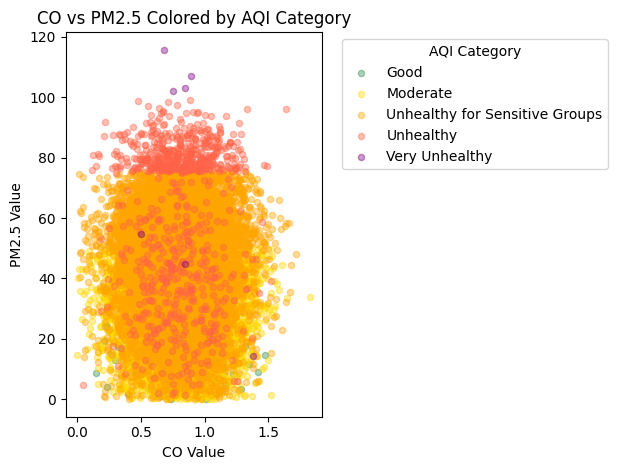

In [10]:
# Q9: Scatter plot of co vs pm25 colored by aqi_category

import matplotlib.pyplot as plt

# Step 1: Create aqi_category column if not already present
def aqi_category(val):
    if val <= 50:    return 'Good'
    elif val <= 100: return 'Moderate'
    elif val <= 150: return 'Unhealthy for Sensitive Groups'
    elif val <= 200: return 'Unhealthy'
    elif val <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

if 'aqi_category' not in df.columns:
    df['aqi_category'] = df['aqi'].apply(aqi_category)

# Step 2: Define a color for each category manually
color_map = {
    'Good':                          'seagreen',
    'Moderate':                      'gold',
    'Unhealthy for Sensitive Groups':'orange',
    'Unhealthy':                     'tomato',
    'Very Unhealthy':                'purple',
    'Hazardous':                     'maroon'
}

# Step 3: Drop rows with missing values in either column
scatter_df = df[['co', 'pm25', 'aqi_category']].dropna()

# Step 4: Plot each category separately so legend labels work correctly
for category, color in color_map.items():
    subset = scatter_df[scatter_df['aqi_category'] == category]
    if subset.empty:                 # skip categories absent from data
        continue
    plt.scatter(
        subset['co'],
        subset['pm25'],
        color=color,
        alpha=0.4,
        label=category,
        s=20                         # point size — smaller avoids clutter
    )

# Step 5: Labels, title, legend
plt.xlabel('CO Value')
plt.ylabel('PM2.5 Value')
plt.title('CO vs PM2.5 Colored by AQI Category')
plt.legend(
    title='AQI Category',
    bbox_to_anchor=(1.05, 1),        # place legend outside plot to avoid overlap
    loc='upper left'
)

plt.tight_layout()
plt.show()

### How it works

- `color_map` is a plain dictionary that assigns one named color to each AQI category — colors follow the real-world AQI scale (green = good, maroon = hazardous).
- We loop over `color_map` and call `plt.scatter()` **once per category** — this is the standard trick to get a per-category legend, because each `plt.scatter()` call produces one legend entry via `label=category`.
- If we had called `plt.scatter()` once with all points, we would need a colorbar instead of a legend — the loop approach is simpler and more readable.
- `if subset.empty: continue` safely skips any category that has no rows in the data, preventing empty legend entries.
- `bbox_to_anchor=(1.05, 1)` moves the legend just outside the right edge of the plot — with 6 categories, placing it inside would cover the data points.

**Key takeaway:** To color scatter points by category with a legend, loop over categories and call `plt.scatter()` once per group with a `label` — a single call with mixed colors cannot produce named legend entries automatically.

**Q10.** Save any one of your previous plots to a file called `aqi_plot.png` using `plt.savefig('aqi_plot.png', dpi=150, bbox_inches='tight')`. Print a confirmation message after saving.

Plot saved successfully as 'aqi_plot.png'


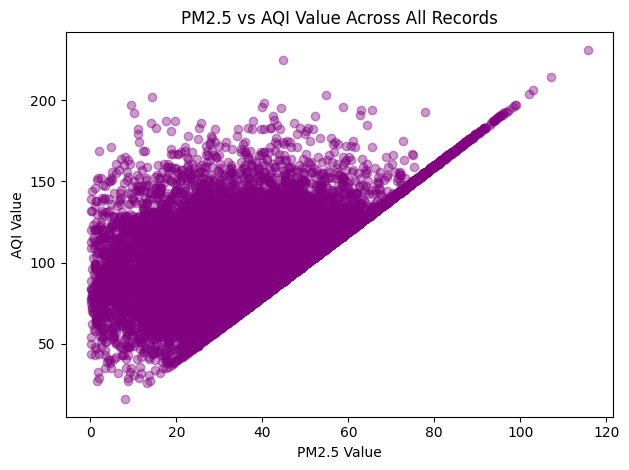

In [11]:
# Q10: Recreate Q5 scatter plot and save to aqi_plot.png

import matplotlib.pyplot as plt

# Step 1: Recreate the Q5 scatter plot (co vs pm25)
scatter_df = df[['pm25', 'aqi']].dropna()

plt.scatter(
    scatter_df['pm25'],
    scatter_df['aqi'],
    alpha=0.4,
    color='purple'
)

plt.xlabel('PM2.5 Value')
plt.ylabel('AQI Value')
plt.title('PM2.5 vs AQI Value Across All Records')
plt.tight_layout()

# Step 2: Save the figure BEFORE plt.show() — show() clears the figure
plt.savefig('aqi_plot.png', dpi=150, bbox_inches='tight')

# Step 3: Confirm save, then display
print("Plot saved successfully as 'aqi_plot.png'")
plt.show()

### How it works

- `plt.savefig()` must always be called **before** `plt.show()` — `plt.show()` flushes and clears the current figure from memory, so saving after it produces a blank file.
- `dpi=150` sets the resolution to 150 dots per inch — higher DPI means a sharper image, useful for reports or presentations.
- `bbox_inches='tight'` automatically crops the saved image to remove extra whitespace around the plot, including any legend or label that extends slightly outside the default plot boundary.
- The filename `'aqi_plot.png'` saves to the current working directory; you can provide a full path like `'/content/aqi_plot.png'` in Colab to control exactly where it lands.
- `print()` after `savefig()` confirms the file was written without error — useful when running notebooks non-interactively.

**Key takeaway:** Always call `plt.savefig()` before `plt.show()` — this is the single most common mistake when saving Matplotlib figures, and the resulting blank file can be confusing to debug.

**Q11.** Create a **vertical bar chart** of the top 10 countries by **average AQI Value**. Rotate the x-axis labels by 45 degrees using `plt.xticks(rotation=45)`. Add value labels on top of each bar using `ax.text()` or `plt.text()`.

country
QA    107.366667
NG    106.616667
SG    106.480556
PK    106.300000
RU    106.197222
ZA    106.158333
EG    106.052778
AR    105.950000
FR    105.763889
CH    105.722222
Name: aqi, dtype: float64


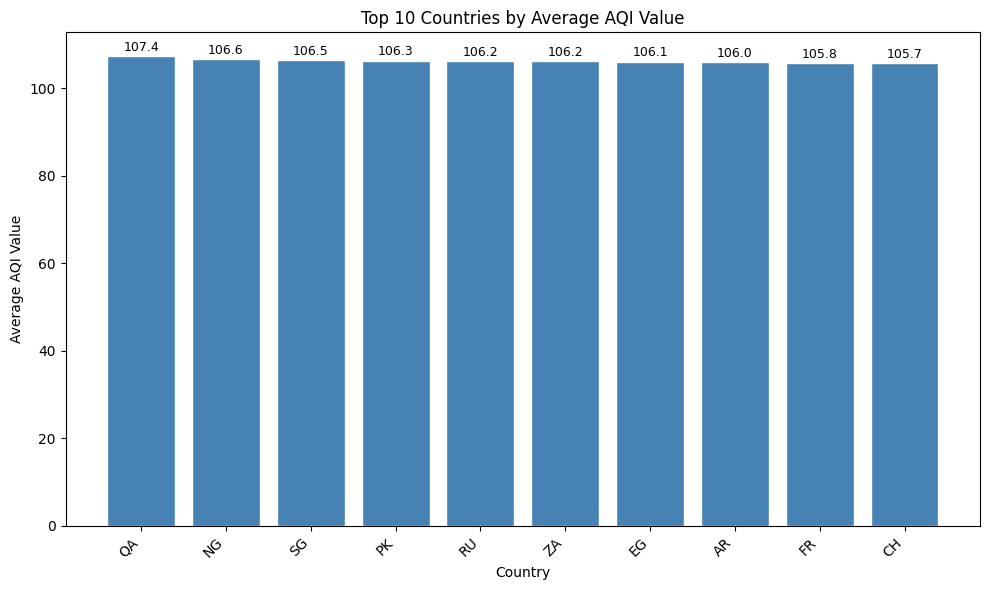

In [12]:
# Q11: Vertical bar chart — top 10 countries by average AQI, with value labels

import matplotlib.pyplot as plt

# Step 1: Compute average AQI per country, take top 10
top10_countries = (
    df.groupby('country')['aqi']
    .mean()
    .nlargest(10)
    .sort_values(ascending=False)   # highest bar on the left
)
print(top10_countries)

# Step 2: Create figure and axes explicitly (needed for ax.text())
fig, ax = plt.subplots(figsize=(10, 6))

# Step 3: Draw vertical bar chart
bars = ax.bar(
    top10_countries.index,
    top10_countries.values,
    color='steelblue',
    edgecolor='white'
)

# Step 4: Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()           # get the bar's height (= AQI value)
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x: center of the bar
        height + 0.5,                        # y: just above the bar top
        f'{height:.1f}',                     # label text: 1 decimal place
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=9
    )

# Step 5: Labels, title, rotated x ticks
plt.xticks(rotation=45, ha='right')    # ha='right' aligns rotated labels neatly
plt.xlabel('Country')
plt.ylabel('Average AQI Value')
plt.title('Top 10 Countries by Average AQI Value')

plt.tight_layout()
plt.show()

### How it works

- `ax.bar()` returns a list of `Rectangle` objects called `bars` — one per country. We iterate over them to place labels.
- `bar.get_height()` reads the bar's actual height (the AQI value), so the label always matches the bar exactly.
- `bar.get_x() + bar.get_width() / 2` calculates the horizontal center of each bar — placing text at this x position keeps the label centered above the bar.
- `height + 0.5` shifts the label slightly above the bar top so it does not sit directly on the edge.
- `ha='center'` and `va='bottom'` control text alignment — center horizontally, anchored at the bottom of the text box so it grows upward.
- `plt.xticks(rotation=45, ha='right')` rotates labels 45 degrees and right-aligns them so each label points toward its bar rather than drifting to the side.

**Key takeaway:** To add value labels on bars, loop over the `bars` list returned by `ax.bar()` and use `ax.text()` with `bar.get_x() + bar.get_width() / 2` for x and `bar.get_height()` for y — this keeps labels perfectly centered and dynamically correct for any data.

**Q12.** Create a figure with two subplots **side by side** (`plt.subplots(1, 2)`):
- Left: scatter plot of `Ozone AQI Value` vs `AQI Value`
- Right: scatter plot of `NO2 AQI Value` vs `AQI Value`
Share the y-axis (`sharey=True`). Add a main title using `fig.suptitle()`.

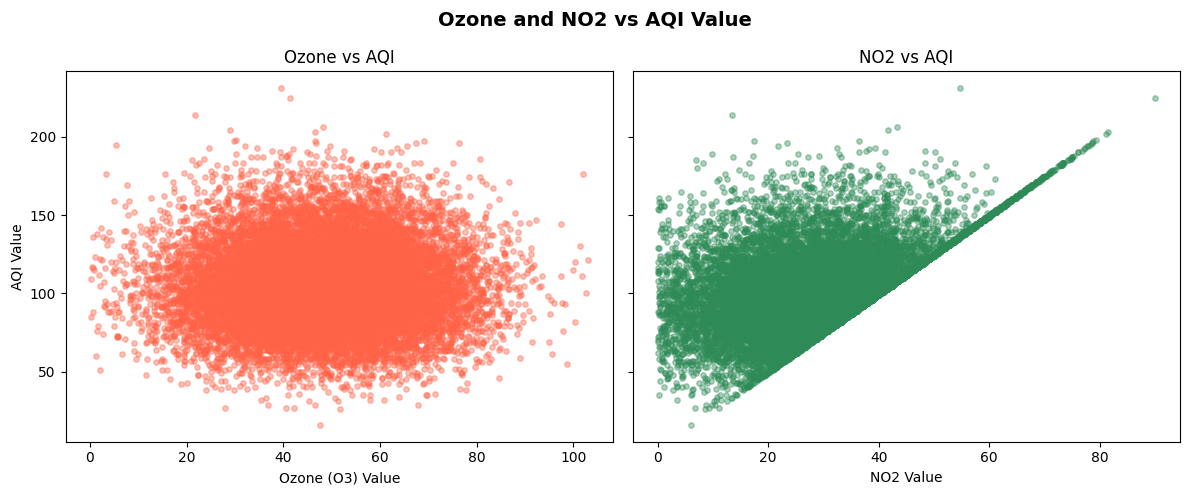

In [13]:
# Q12: Side-by-side scatter plots — o3 vs aqi and no2 vs aqi, shared y-axis

import matplotlib.pyplot as plt

# Step 1: Create 1x2 subplot grid with shared y-axis
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Step 2: Drop missing values for each pair independently
df_o3  = df[['o3',  'aqi']].dropna()
df_no2 = df[['no2', 'aqi']].dropna()

# Step 3: Left — Ozone vs AQI
ax[0].scatter(
    df_o3['o3'],
    df_o3['aqi'],
    alpha=0.4,
    color='tomato',
    s=15                            # smaller point size for dense data
)
ax[0].set_xlabel('Ozone (O3) Value')
ax[0].set_ylabel('AQI Value')       # only needed on left when sharey=True
ax[0].set_title('Ozone vs AQI')

# Step 4: Right — NO2 vs AQI
ax[1].scatter(
    df_no2['no2'],
    df_no2['aqi'],
    alpha=0.4,
    color='seagreen',
    s=15
)
ax[1].set_xlabel('NO2 Value')
# y-axis label omitted on right — sharey=True shares the ticks and label
ax[1].set_title('NO2 vs AQI')

# Step 5: Main title and layout
fig.suptitle('Ozone and NO2 vs AQI Value', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### How it works

- `plt.subplots(1, 2)` creates one row and two columns of subplots — `ax` is a 1D array so panels are accessed as `ax[0]` and `ax[1]`, not `ax[row, col]`.
- `sharey=True` links both subplots to the same y-axis scale — if AQI ranges from 0 to 500 in one panel, the other uses the same range automatically, making visual comparison fair and honest.
- When `sharey=True`, Matplotlib hides the y-axis tick labels on the right panel to avoid repetition — so we only call `ax[0].set_ylabel()` on the left.
- Each `dropna()` is done independently on its own column pair — this avoids accidentally removing rows that are only missing in one pollutant but valid in the other.
- `fig.suptitle()` adds one title above both subplots; `fontweight='bold'` makes it visually distinct from the individual subplot titles below it.
- `plt.tight_layout()` adjusts spacing after `suptitle` so the main title does not overlap the subplot titles.

**Key takeaway:** `sharey=True` is essential when placing related scatter plots side by side — without it, each panel auto-scales independently and differences in spread can create a misleading visual comparison.

**Q13.** Filter to cities where `AQI Category == "Unhealthy"`. Create a bar chart of the top 10 cities by `AQI Value`. Highlight the highest-AQI bar with a different color from the rest.

city
Zurich       168.933333
Kolkata      166.416667
Karachi      166.047619
Hong Kong    165.846154
Bangkok      165.800000
Riyadh       165.777778
Doha         165.000000
Warsaw       164.789474
New York     164.782609
Melbourne    164.750000
Name: aqi, dtype: float64


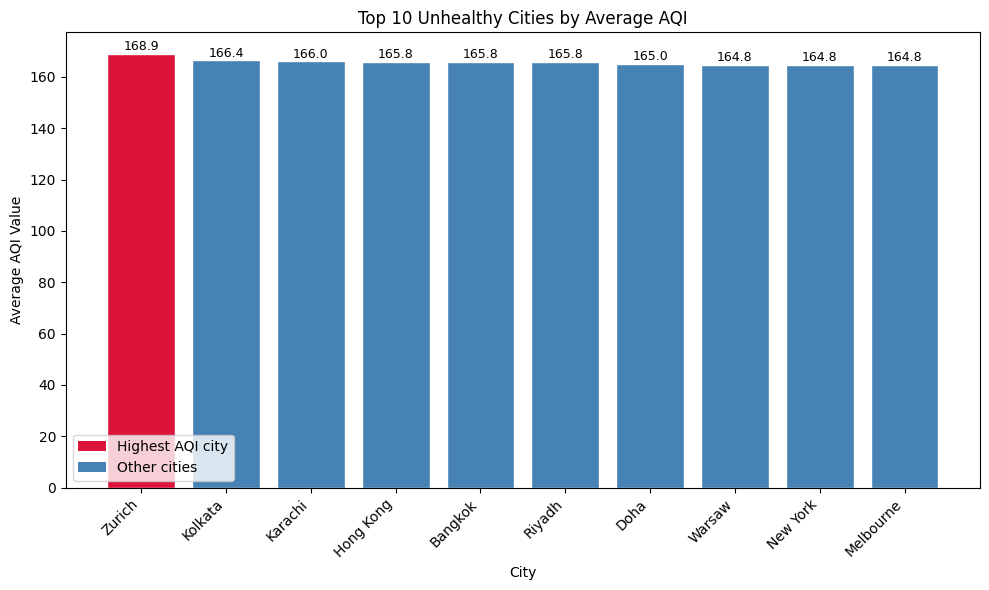

In [14]:
# Q13: Bar chart — top 10 'Unhealthy' cities, highest bar highlighted

import matplotlib.pyplot as plt

# Step 1: Create aqi_category column if not already present
def aqi_category(val):
    if val <= 50:    return 'Good'
    elif val <= 100: return 'Moderate'
    elif val <= 150: return 'Unhealthy for Sensitive Groups'
    elif val <= 200: return 'Unhealthy'
    elif val <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

if 'aqi_category' not in df.columns:
    df['aqi_category'] = df['aqi'].apply(aqi_category)

# Step 2: Filter to 'Unhealthy' rows only
unhealthy_df = df[df['aqi_category'] == 'Unhealthy']

# Step 3: Top 10 cities by mean AQI within 'Unhealthy' category
top10 = (
    unhealthy_df.groupby('city')['aqi']
    .mean()
    .nlargest(10)
    .sort_values(ascending=False)   # highest bar on the left
)
print(top10)

# Step 4: Build color list — highlight the highest bar in crimson
colors = ['crimson'] + ['steelblue'] * (len(top10) - 1)
# index 0 is the highest city after sort_values(ascending=False)

# Step 5: Draw bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    top10.index,
    top10.values,
    color=colors,
    edgecolor='white'
)

# Step 6: Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Step 7: Add a legend to explain the highlight
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson',   label='Highest AQI city'),
    Patch(facecolor='steelblue', label='Other cities')
]
ax.legend(handles=legend_elements)

# Step 8: Labels, title, rotated ticks
plt.xticks(rotation=45, ha='right')
plt.xlabel('City')
plt.ylabel('Average AQI Value')
plt.title('Top 10 Unhealthy Cities by Average AQI')

plt.tight_layout()
plt.show()

### How it works

- `df[df['aqi_category'] == 'Unhealthy']` filters rows where AQI falls between 151–200, keeping only the "Unhealthy" band.
- After `.sort_values(ascending=False)`, the highest-AQI city is always at index position 0 — so `colors = ['crimson'] + ['steelblue'] * 9` paints exactly that first bar differently without any extra logic.
- Passing a `list` of colors to `ax.bar()` assigns one color per bar in order — Matplotlib accepts either a single color string or a list of the same length as the data.
- `matplotlib.patches.Patch` creates a colored rectangle for the legend — since bars are not plotted in separate `ax.bar()` calls (unlike Q9), we manually build legend entries this way.
- Value labels reuse the same `bar.get_height()` pattern from Q11 — once learned, this pattern applies to any bar chart.

**Key takeaway:** To highlight one specific bar, build a color list where position 0 (or whichever rank you want) gets a distinct color and the rest get a default — passing a list to `color=` in `ax.bar()` gives you per-bar color control with no extra code.

**Q14.** Create a **stacked bar chart** showing average `CO AQI Value`, `Ozone AQI Value`, and `NO2 AQI Value` for the top 5 countries. Each bar should show all three pollutants stacked.

Top 5 countries: ['IN', 'US', 'AU', 'CA', 'CN']
               co         o3        no2
country                                
AU       0.791719  48.271247  31.588029
CA       0.797586  46.920361  31.626839
CN       0.792401  48.017615  32.018786
IN       0.815755  47.948462  31.996357
US       0.796457  48.608489  31.375478


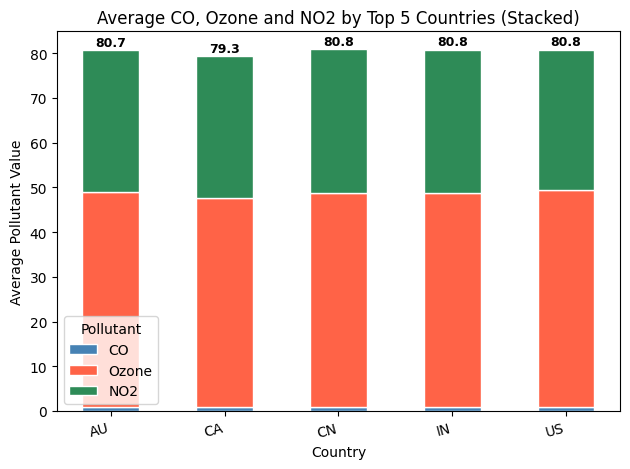

In [15]:
# Q14: Stacked bar chart — avg co, o3, no2 for top 5 countries

import matplotlib.pyplot as plt
import numpy as np

# Step 1: Find top 5 countries by number of unique cities (consistent with Q6)
top5_countries = (
    df.groupby('country')['city']
    .nunique()
    .nlargest(5)
    .index
    .tolist()
)
print("Top 5 countries:", top5_countries)

# Step 2: Filter and compute mean of each pollutant per country
filtered = df[df['country'].isin(top5_countries)]
grouped = filtered.groupby('country')[['co', 'o3', 'no2']].mean()
print(grouped)

# Step 3: Set up bar positions
x = np.arange(len(grouped))
bar_width = 0.5

# Step 4: Draw stacked bars — each pollutant starts where the previous one ended
bars_co = plt.bar(
    x,
    grouped['co'],
    width=bar_width,
    label='CO',
    color='steelblue',
    edgecolor='white'
)

bars_o3 = plt.bar(
    x,
    grouped['o3'],
    width=bar_width,
    bottom=grouped['co'],                       # stack on top of CO
    label='Ozone',
    color='tomato',
    edgecolor='white'
)

bars_no2 = plt.bar(
    x,
    grouped['no2'],
    width=bar_width,
    bottom=grouped['co'] + grouped['o3'],       # stack on top of CO + Ozone
    label='NO2',
    color='seagreen',
    edgecolor='white'
)

# Step 5: Add total value label on top of each full stack
for i, (co, o3, no2) in enumerate(zip(grouped['co'], grouped['o3'], grouped['no2'])):
    total = co + o3 + no2
    plt.text(
        i,
        total + 0.3,                            # just above the top of the stack
        f'{total:.1f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Step 6: Labels, title, legend, ticks
plt.xticks(ticks=x, labels=grouped.index, rotation=15, ha='right')
plt.xlabel('Country')
plt.ylabel('Average Pollutant Value')
plt.title('Average CO, Ozone and NO2 by Top 5 Countries (Stacked)')
plt.legend(title='Pollutant')

plt.tight_layout()
plt.show()

### How it works

- A stacked bar chart uses the same x positions for all pollutants — the key is the `bottom` parameter, which tells Matplotlib where each layer starts.
- The first layer (`co`) has no `bottom` — it starts at zero.
- The second layer (`o3`) sets `bottom=grouped['co']` — it starts where CO ends.
- The third layer (`no2`) sets `bottom=grouped['co'] + grouped['o3']` — it starts where CO and Ozone together end.
- `zip(grouped['co'], grouped['o3'], grouped['no2'])` iterates over all three columns row by row simultaneously, so we can compute each bar's total height for the label.
- The total label is placed at `total + 0.3` — just above the top of the full stack — giving a quick read of the combined pollutant burden per country.

**Key takeaway:** The `bottom` parameter is the entire mechanism behind stacked bars — each new layer's `bottom` must equal the sum of all layers beneath it, so the segments sit flush on top of each other with no gaps or overlaps.

**Q15.** Plot a simple **line chart** comparing the number of cities in each `AQI Category` (x = category, y = city count). Use a custom color `"#2ecc71"`, add grid lines with `plt.grid(True, linestyle='--', alpha=0.7)`, and add a title.

aqi_category
Good                              48
Moderate                          50
Unhealthy for Sensitive Groups    50
Unhealthy                         50
Very Unhealthy                     6
Name: city, dtype: int64


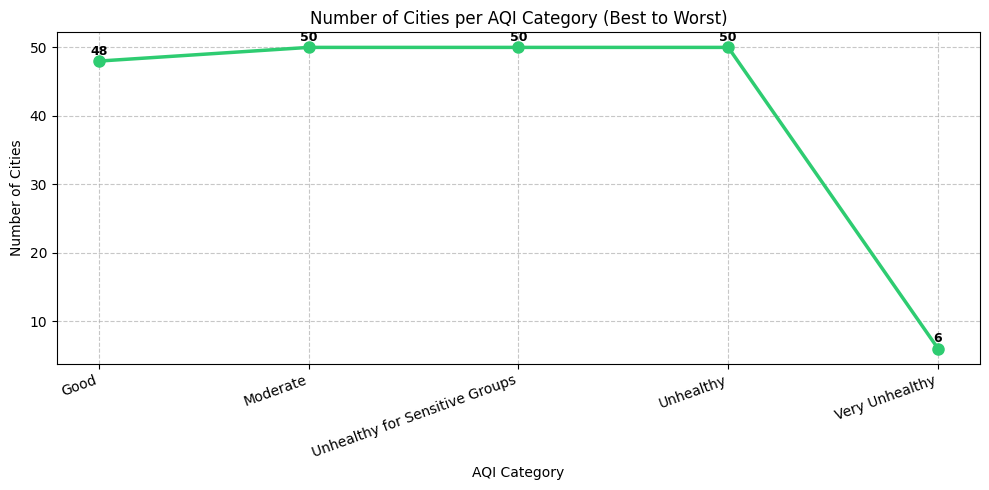

In [16]:
# Q15: Line chart — city count per AQI category, best to worst order

import matplotlib.pyplot as plt

# Step 1: Create aqi_category column if not already present
def aqi_category(val):
    if val <= 50:    return 'Good'
    elif val <= 100: return 'Moderate'
    elif val <= 150: return 'Unhealthy for Sensitive Groups'
    elif val <= 200: return 'Unhealthy'
    elif val <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

if 'aqi_category' not in df.columns:
    df['aqi_category'] = df['aqi'].apply(aqi_category)

# Step 2: Count unique cities per AQI category
city_counts = (
    df.groupby('aqi_category')['city']
    .nunique()                          # count distinct cities, not rows
)

# Step 3: Enforce best → worst order, drop absent categories
category_order = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]
city_counts = city_counts.reindex(
    [c for c in category_order if c in city_counts.index]
)
print(city_counts)

# Step 4: Draw line chart
plt.figure(figsize=(10, 5))
plt.plot(
    city_counts.index,
    city_counts.values,
    color='#2ecc71',
    marker='o',
    linewidth=2.5,
    markersize=8
)

# Step 5: Annotate each point with its city count
for i, (cat, count) in enumerate(city_counts.items()):
    plt.text(
        i,
        count + 0.5,                    # slightly above the marker
        str(count),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Step 6: Grid, labels, title
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=20, ha='right')
plt.xlabel('AQI Category')
plt.ylabel('Number of Cities')
plt.title('Number of Cities per AQI Category (Best to Worst)')

plt.tight_layout()
plt.show()

### How it works

- `.nunique()` counts **distinct** city names per category — without it, we would count rows (hourly records), which is far larger and not what the question asks.
- `.reindex()` enforces the meaningful best-to-worst order so the line moves in a logical direction rather than alphabetical order, which would produce a misleading zigzag.
- `color='#2ecc71'` is a hex color code — the six digits after `#` define the exact RGB color (a fresh green in this case). Any HTML hex color works the same way in Matplotlib.
- `plt.grid(True, linestyle='--', alpha=0.7)` adds dashed grid lines at 70% opacity — visible enough to help read values off the chart without overpowering the data line.
- The annotation loop uses `enumerate(city_counts.items())` to get both `i` (integer x position for `plt.text()`) and `count` (the label value) in one pass.

**Key takeaway:** `plt.grid()` is a one-line addition that dramatically improves readability for line charts — `linestyle='--'` and `alpha` keep it subtle so it guides the eye without competing with the plotted data.